Import modules, define network and apply transformations

In [1]:
import torch
from torchvision.datasets import Flowers102
import scipy
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class FlowersNetwork(nn.Module):
    def __init__(self, in_channels, out_features, activation_function = F.relu):
        super(FlowersNetwork, self).__init__()

        # Define convolutional layers
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Define max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Define fully connected layers
        self.fc1 = nn.Linear(int(32*56*56), 512)
        self.fc2 = nn.Linear(512, out_features)

        self.activation_function = activation_function

    def forward(self, x):
        x = self.pool(self.activation_function(self.conv1(x)))
        x = self.pool(self.activation_function(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.activation_function(self.fc1(x))
        x = self.fc2(x)
        return x

# Set image dimensions
imageWidth = 224
imageHeight = 224

# Define batch size
batch_size = 32

# Calculate mean and standard deviation of the dataset for normalisation
flowersTransform_no_norm = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor()
])

flowersTrain_no_norm = Flowers102(root="./data", split="train", download=True, transform=flowersTransform_no_norm)
train_no_norm_loader = DataLoader(flowersTrain_no_norm, batch_size=batch_size, shuffle=False)

mean = 0.
std = 0.
total_samples = 0

for images, _ in train_no_norm_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

# Apply transformations to dataset
flowersTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

flowersTrain = Flowers102(root = "./data", split = "train", download=True, transform = flowersTransform)
flowersTest = Flowers102(root = "./data", split = "test", download=True, transform = flowersTransform)

# Move model onto GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DataLoaders for batch usage
train_loader = DataLoader(flowersTrain, batch_size=batch_size, shuffle=True)

imageChannels = 3 #R,G,B
imageSize = imageWidth*imageHeight*imageChannels


Initialise classifier, optimiser and loss function. Then train the model and output loss per epoch.

Epoch 1 - 4.703628316521645
Epoch 2 - 4.116935715079308
Epoch 3 - 3.3622644245624542
Epoch 4 - 2.3770904541015625
Epoch 5 - 1.4526949729770422
Epoch 6 - 0.8110273163765669
Epoch 7 - 0.4143991698510945
Epoch 8 - 0.2036777762696147
Epoch 9 - 0.10859541420359164
Epoch 10 - 0.04515736410394311
Epoch 11 - 0.02665479850838892
Epoch 12 - 0.01754057573270984
Epoch 13 - 0.013147191843017936
Epoch 14 - 0.010918117593973875
Epoch 15 - 0.009341590470285155
Epoch 16 - 0.00794138599303551
Epoch 17 - 0.006832148785179015
Epoch 18 - 0.006049860647181049
Epoch 19 - 0.00539697143540252
Epoch 20 - 0.0048513062138226815
Epoch 21 - 0.004451369815797079
Epoch 22 - 0.003952932347601745
Epoch 23 - 0.003603251367167104
Epoch 24 - 0.003291652086772956
Epoch 25 - 0.003024924921191996
Epoch 26 - 0.002777859910565894
Epoch 27 - 0.0025837710418272763
Epoch 28 - 0.0024014809023356065
Epoch 29 - 0.00223513358287164
Epoch 30 - 0.002077287990687182
Epoch 31 - 0.00195418430303107
Epoch 32 - 0.0018308408398297615
Epoch 3

Text(0.5, 0, 'Epoch')

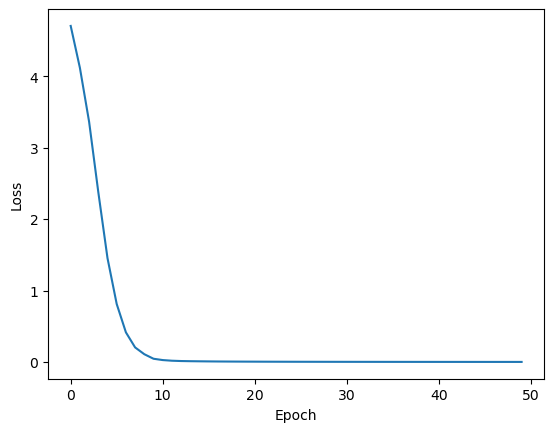

In [2]:
classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.relu)

# Move model to GPU
classifier.to(device)

lossFunction = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(classifier.parameters(), lr=0.0001)

classifier.train()
epochs = 50
patience = 3 
losses = []
for i in range(epochs):
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch {i+1} - {epochLoss}")

# Plot graph
plt.plot(range(len(losses)), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

Calculate model accuracy

In [3]:
with torch.no_grad():
  classifier.eval()
  accuracyTolerance = 0.5
  correct = 0
  total = 0
  test_loader = DataLoader(flowersTest, batch_size=1)
  for images, labels in test_loader:
        images = images.to(device)
        predictions = classifier.forward(images)
        _, predictedClass = torch.max(predictions, dim=1)

        total += 1
        print(f"Predicted - {predictedClass.item()}")
        print(f"Actual - {labels.item()}")
        if abs(int(predictedClass.item()) - labels.item()) <= accuracyTolerance:
            correct += 1
  accuracy = correct / total
  print(f"Model Accuracy: {accuracy}")

Predicted - 0
Actual - 0
Predicted - 56
Actual - 0
Predicted - 50
Actual - 0
Predicted - 68
Actual - 0
Predicted - 50
Actual - 0
Predicted - 48
Actual - 0
Predicted - 69
Actual - 0
Predicted - 0
Actual - 0
Predicted - 90
Actual - 0
Predicted - 74
Actual - 0
Predicted - 69
Actual - 0
Predicted - 1
Actual - 0
Predicted - 48
Actual - 0
Predicted - 54
Actual - 0
Predicted - 72
Actual - 0
Predicted - 94
Actual - 0
Predicted - 85
Actual - 0
Predicted - 30
Actual - 0
Predicted - 32
Actual - 0
Predicted - 0
Actual - 0
Predicted - 51
Actual - 1
Predicted - 1
Actual - 1
Predicted - 94
Actual - 1
Predicted - 1
Actual - 1
Predicted - 18
Actual - 1
Predicted - 1
Actual - 1
Predicted - 1
Actual - 1
Predicted - 1
Actual - 1
Predicted - 1
Actual - 1
Predicted - 37
Actual - 1
Predicted - 1
Actual - 1
Predicted - 1
Actual - 1
Predicted - 74
Actual - 1
Predicted - 17
Actual - 1
Predicted - 1
Actual - 1
Predicted - 39
Actual - 1
Predicted - 74
Actual - 1
Predicted - 1
Actual - 1
Predicted - 31
Actual - 1


Model's accuracy (on my run): 14.6% - quite low, but much better than randomly picking.
CNN model is already much better than the linear model. The model would likely benefit from more convolutional layers.
Experimenting with kernel size, optimisers, activation functions and learning rate could also be beneficial.